<a href="https://colab.research.google.com/github/reneta-dimitrova96/Deep-Learning-Course-Project-2026/blob/main/notebooks/05_Model_Comparison_and_Error_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Comparison and Error Analysis

## Notebook Objective

This notebook compares the results of the three approaches used in the project: TF-IDF with Logistic Regression, Siamese BiLSTM and DistilBERT.

The models are compared using the same evaluation metrics. The best-performing model is also examined in more detail through error analysis.

The project uses the PAWS-Wiki Labeled (Final) dataset. The PAWS-Wiki dataset was released by Google Research and is used in this project for educational purposes. Google LLC (Google) is acknowledged as the data source.

## Sources

- [PAWS-Wiki Dataset on Hugging Face](https://huggingface.co/datasets/google-research-datasets/paws)
- [Official PAWS Repository by Google Research](https://github.com/google-research-datasets/paws)
- [PAWS: Paraphrase Adversaries from Word Scrambling](https://arxiv.org/abs/1904.01130)
- [DistilBERT Base Uncased on Hugging Face](https://huggingface.co/distilbert/distilbert-base-uncased)
- [DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter](https://arxiv.org/abs/1910.01108)

## 1. Setup and Imports

The required libraries are imported for comparing the model results and analyzing prediction errors.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## 2. Loading Model Predictions

The saved test predictions from the three models are loaded so that their results can be compared using the same test examples.
The prediction files used in this notebook were generated from the final models evaluated in the previous notebooks.
They are not included in the repository because they contain sentence text from the dataset. The saved notebook outputs are kept to document the model comparison and error analysis.

In [ ]:
tfidf_predictions = pd.read_csv(
    "tfidf_logreg_test_predictions.csv"
)

siamese_predictions = pd.read_csv(
    "siamese_bilstm_test_predictions.csv"
)

distilbert_predictions = pd.read_csv(
    "distilbert_test_predictions.csv"
)

## 3. Checking the Prediction Files

Before comparing the models, the prediction files are checked to make sure that they contain the same test examples and labels.

In [ ]:
print("TF-IDF:", tfidf_predictions.shape)
print("Siamese BiLSTM:", siamese_predictions.shape)
print("DistilBERT:", distilbert_predictions.shape)

TF-IDF: (7977, 6)
Siamese BiLSTM: (7977, 6)
DistilBERT: (7977, 6)


In [ ]:
same_ids = (
    tfidf_predictions["id"].equals(siamese_predictions["id"])
    and
    tfidf_predictions["id"].equals(distilbert_predictions["id"])
)

same_labels = (
    tfidf_predictions["y_true"].equals(siamese_predictions["y_true"])
    and
    tfidf_predictions["y_true"].equals(distilbert_predictions["y_true"])
)

print("Same test examples:", same_ids)
print("Same true labels:", same_labels)

Same test examples: True
Same true labels: True


## 4. Model Performance Comparison

The evaluation metrics are calculated directly from the saved test predictions for each model.
For precision, recall and F1-score, the paraphrase class (label = 1) is treated as the positive class.

In [ ]:
def calculate_metrics(predictions_df):
    return {
        "Accuracy": accuracy_score(
            predictions_df["y_true"],
            predictions_df["y_pred"]
        ),
        "Precision": precision_score(
            predictions_df["y_true"],
            predictions_df["y_pred"]
        ),
        "Recall": recall_score(
            predictions_df["y_true"],
            predictions_df["y_pred"]
        ),
        "F1-score": f1_score(
            predictions_df["y_true"],
            predictions_df["y_pred"]
        )
    }

In [ ]:
tfidf_metrics = calculate_metrics(tfidf_predictions)
siamese_metrics = calculate_metrics(siamese_predictions)
distilbert_metrics = calculate_metrics(distilbert_predictions)

In [ ]:
model_comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        **tfidf_metrics
    },
    {
        "Model": "Siamese BiLSTM",
        **siamese_metrics
    },
    {
        "Model": "DistilBERT",
        **distilbert_metrics
    }
])

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.5295,0.4718,0.5521,0.5088
1,Siamese BiLSTM,0.7415,0.6856,0.7654,0.7233
2,DistilBERT,0.8844,0.8453,0.9034,0.8734


## 5. Visual Comparison

The test results are visualized to make the differences between the three models easier to compare.

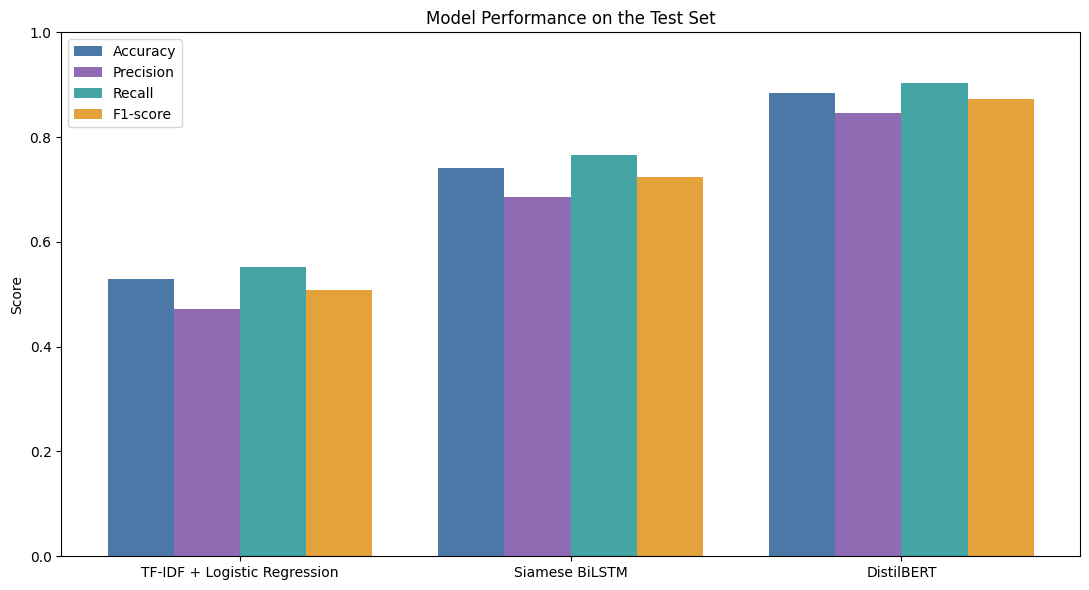

In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

colors = [
    "#4C78A8",
    "#8F6BB3",
    "#45A5A5",
    "#E3A33A"
]

x = np.arange(len(model_comparison))
width = 0.2

plt.figure(figsize=(11, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        model_comparison[metric],
        width,
        label=metric,
        color=colors[i]
    )

plt.xticks(
    x + width * 1.5,
    model_comparison["Model"]
)

plt.ylabel("Score")
plt.title("Model Performance on the Test Set")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

The results show a clear improvement from the baseline model to the deep learning models.

The Siamese BiLSTM performs better than TF-IDF with Logistic Regression, while DistilBERT achieves the highest scores across all four evaluation metrics.

## 6. Error Analysis

The prediction errors are analyzed to better understand the differences between the three models and identify sentence pairs that are more difficult to classify.
Long sentence texts are truncated in the displayed tables for readability.

In [ ]:
error_analysis_df = pd.DataFrame({
    "id": distilbert_predictions["id"],
    "sentence1": distilbert_predictions["sentence1"],
    "sentence2": distilbert_predictions["sentence2"],
    "y_true": distilbert_predictions["y_true"],
    "tfidf_pred": tfidf_predictions["y_pred"],
    "siamese_pred": siamese_predictions["y_pred"],
    "distilbert_pred": distilbert_predictions["y_pred"]
})

error_analysis_df.head()

,id,sentence1,sentence2,y_true,tfidf_pred,siamese_pred,distilbert_pred
0,1,This was a series of nested angular standards ...,"This was a series of nested polar scales , so ...",0,0,1,0
1,2,His father emigrated to Missouri in 1868 but r...,"His father emigrated to America in 1868 , but ...",0,1,0,0
2,3,"In January 2011 , the Deputy Secretary General...","In January 2011 , FIBA Asia deputy secretary g...",1,0,0,1
3,4,"Steiner argued that , in the right circumstanc...",Steiner held that the spiritual world can be r...,0,1,0,0
4,5,"Luciano Williames Dias ( born July 25 , 1970 )...",Luciano Williames Dias ( born 25 July 1970 ) i...,0,1,0,0


In [ ]:
error_analysis_df["tfidf_error"] = (
    error_analysis_df["tfidf_pred"]
    != error_analysis_df["y_true"]
)

error_analysis_df["siamese_error"] = (
    error_analysis_df["siamese_pred"]
    != error_analysis_df["y_true"]
)

error_analysis_df["distilbert_error"] = (
    error_analysis_df["distilbert_pred"]
    != error_analysis_df["y_true"]
)

In [ ]:
print(
    "TF-IDF errors:",
    error_analysis_df["tfidf_error"].sum()
)

print(
    "Siamese BiLSTM errors:",
    error_analysis_df["siamese_error"].sum()
)

print(
    "DistilBERT errors:",
    error_analysis_df["distilbert_error"].sum()
)

TF-IDF errors: 3753
Siamese BiLSTM errors: 2062
DistilBERT errors: 922


The number of prediction errors decreases considerably across the three models. TF-IDF with Logistic Regression makes the most errors, while DistilBERT makes the fewest.

This is consistent with the test metrics and shows the improvement from the baseline model to the transformer-based approach.

### Examples Correctly Classified Only by DistilBERT

The following examples were misclassified by both TF-IDF and Siamese BiLSTM, while DistilBERT predicted the correct label.

In [ ]:
distilbert_better_examples = error_analysis_df[
    (error_analysis_df["tfidf_error"]) &
    (error_analysis_df["siamese_error"]) &
    (~error_analysis_df["distilbert_error"])
]

print(
    "Number of examples:",
    len(distilbert_better_examples)
)

Number of examples: 732


In [ ]:
distilbert_better_examples[
    [
        "sentence1",
        "sentence2",
        "y_true",
        "tfidf_pred",
        "siamese_pred",
        "distilbert_pred"
    ]
].head(5)

,sentence1,sentence2,y_true,tfidf_pred,siamese_pred,distilbert_pred
2,"In January 2011 , the Deputy Secretary General...","In January 2011 , FIBA Asia deputy secretary g...",1,0,0,1
6,The smallest number that can be represented in...,The smallest number that can be represented as...,0,1,1,0
36,"On December 1 , Tinnish announced that he had ...","On 1 December , Tinnish announced that he had ...",0,1,1,0
94,At the bottom of the hydrometer is a weighted ...,At the bottom of the hydrometer there is a wei...,1,0,0,1
103,Ruffell was employed as an engineer in Southam...,Ruffell was employed as an engineer in Southam...,1,0,0,1


There are 732 test examples that were classified correctly by DistilBERT but incorrectly by both TF-IDF and Siamese BiLSTM.

Some of these examples contain very similar words but changes in word order or sentence structure. Others express the same meaning using a different formulation. DistilBERT's contextual representations may help with these cases because they capture contextual and positional information when processing the sentence pair.

### Examples Misclassified by All Models

The following examples were misclassified by all three models. These cases are examined to identify patterns that are difficult for the different approaches used in the project.

In [ ]:
all_models_wrong = error_analysis_df[
    (error_analysis_df["tfidf_error"]) &
    (error_analysis_df["siamese_error"]) &
    (error_analysis_df["distilbert_error"])
]

print(
    "Number of examples:",
    len(all_models_wrong)
)

Number of examples: 307


In [ ]:
all_models_wrong[
    [
        "sentence1",
        "sentence2",
        "y_true",
        "tfidf_pred",
        "siamese_pred",
        "distilbert_pred"
    ]
].head(5)

,sentence1,sentence2,y_true,tfidf_pred,siamese_pred,distilbert_pred
20,Christopher Griffiths ( born Christopher Llewe...,Christopher Llewellyn ( born Christopher Griff...,0,1,1,1
59,Vic participated in many different countries a...,"In many countries , he participated in Vic and...",1,0,0,0
64,"Evariste Baizeau ( June 3 , 1821 - Nantes , Fe...","Anacharsis Evariste Baizeau ( 3 June 1821 , Pa...",1,0,0,0
93,The dictionary form of a verb is the infinitiv...,The dictionary form of a verb is the infinitiv...,0,1,1,1
113,"In physical cosmology , the energy of the cosm...",The energy of the cosmological vacuum appears ...,1,0,0,0


The examples misclassified by all three models highlight some limitations shared across the different approaches.

Several cases contain very similar words but small changes in names, locations, modifiers or word order can change the meaning. Other examples preserve similar information while using substantially different sentence structures.

Some sentence pairs are also linguistically complex or less straightforward to interpret, which can make the correct label more difficult to predict. These examples reflect the challenging sentence pairs included in the PAWS-Wiki Labeled (Final) dataset, where high lexical similarity does not always indicate the same meaning.

### DistilBERT Error Types

DistilBERT errors are separated into false positives and false negatives to examine which type of mistake is more common.

In [ ]:
distilbert_false_positives = error_analysis_df[
    (error_analysis_df["y_true"] == 0) &
    (error_analysis_df["distilbert_pred"] == 1)
]

distilbert_false_negatives = error_analysis_df[
    (error_analysis_df["y_true"] == 1) &
    (error_analysis_df["distilbert_pred"] == 0)
]

print(
    "False positives:",
    len(distilbert_false_positives)
)

print(
    "False negatives:",
    len(distilbert_false_negatives)
)

False positives: 582
False negatives: 340


DistilBERT makes more false positive errors than false negative errors. This is consistent with the higher recall and lower precision for the paraphrase class.

The next step is to examine examples from both error types to better understand which sentence pairs are difficult for the model.

In [ ]:
distilbert_false_positives[
    [
        "sentence1",
        "sentence2",
        "y_true",
        "distilbert_pred"
    ]
].head(5)

,sentence1,sentence2,y_true,distilbert_pred
14,"To get there , take the Marine Drive from the ...","To get there , take Marine Drive west from the...",0,1
20,Christopher Griffiths ( born Christopher Llewe...,Christopher Llewellyn ( born Christopher Griff...,0,1
34,"On July 21 , 2014 , after his two successful y...","On July 21 , 2014 , after his two successful y...",0,1
43,Companies based in the larger rivium include R...,Companies based in the larger Rivium include R...,0,1
45,He built weapons factories for Vtorov and Mikh...,He built weapon factories for Vtorov and Mikhe...,0,1


In [ ]:
distilbert_false_negatives[
    [
        "sentence1",
        "sentence2",
        "y_true",
        "distilbert_pred"
    ]
].head(5)

,sentence1,sentence2,y_true,distilbert_pred
22,Owned by Rick and Sheri Dorritie is Megasaurus...,Megasaurus is owned by Rick and Sheri Dorritie...,1,0
29,"The Nokasippi River , the Mississippi River an...","The Mississippi , the Nokasippi and the Little...",1,0
31,"Some reports state `` 30 years or more '' , wh...","Some reports claim `` 30 years or more '' , wh...",1,0
59,Vic participated in many different countries a...,"In many countries , he participated in Vic and...",1,0
64,"Evariste Baizeau ( June 3 , 1821 - Nantes , Fe...","Anacharsis Evariste Baizeau ( 3 June 1821 , Pa...",1,0


The false positive examples often contain very similar vocabulary, but small changes in names, locations or relationships affect the meaning. This can make the sentence pairs look more similar than they actually are.

The false negative examples show the opposite situation. In several cases, the same information is expressed using a different sentence structure or word order, which can make the paraphrase relationship harder to detect.

Overall, DistilBERT makes fewer false negatives than false positives, which is consistent with its higher recall for the paraphrase class.

### Error Analysis Summary

The error analysis shows that the models can struggle with sentence pairs that have high lexical similarity but important changes in meaning.

DistilBERT handles many of these difficult cases better than the other two models, but some errors remain when small changes in names, relationships or sentence structure affect the interpretation.

The analysis also shows that DistilBERT produces more false positives than false negatives, which matches its higher recall for the paraphrase class.

## 7. Final Summary

The main findings from this notebook are:

- The three models were compared using predictions from the same test set.
- TF-IDF with Logistic Regression achieved the lowest overall performance.
- Siamese BiLSTM improved the results considerably compared with the baseline.
- DistilBERT achieved the best performance across all evaluation metrics, with a test F1-score of **0.8734**.
- The error analysis showed that DistilBERT correctly classified many difficult examples that were missed by the other two models.
- Some challenging cases remain, especially when small changes in names, relationships or sentence structure affect the meaning.

Overall, DistilBERT is selected as the best-performing model for the paraphrase detection task in this project.